# BOUCLIER SAAS — CICIDS-2017 Threat Intelligence Analysis

**Dataset:** Canadian Institute for Cybersecurity — Intrusion Detection System 2017  
**Objective:** Analyze real network attack patterns, train anomaly detection models, and generate actionable threat intelligence.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings("ignore")

# Style
plt.style.use("dark_background")
sns.set_palette("magma")

# Helper for saving plots in either backend/ or backend/notebooks/
def safe_save(filename):
    if os.path.exists("notebooks"):
        path = os.path.join("notebooks", filename)
    else:
        path = filename
    plt.savefig(path, dpi=150, bbox_inches="tight")
    print(f"Saved plot: {path}")

print("Libraries loaded.")

Libraries loaded.


## 1. Data Loading & Exploration

Load the real CICIDS-2017 dataset (sample: ~350K records).

In [2]:
DATA_PATH = "app/ml/data/cicids2017_sample.csv"
if not os.path.exists(DATA_PATH):
    DATA_PATH = "../app/ml/data/cicids2017_sample.csv"
    
df = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Dataset shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
df.head()

Dataset shape: 352,556 rows x 89 columns
Memory usage: 286.3 MB


,Src IP dec,Src Port,Dst IP dec,Dst Port,Protocol,Timestamp,Flow Duration,Total Fwd Packet,Total Bwd packets,Total Length of Fwd Packet,...,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,ICMP Code,ICMP Type,Total TCP Flow Time,Label,Attempted Category
0,2.886730e+09,42374.0,3.232238e+09,80.0,6.0,58:24.9,33000.0,8.0,6.0,336.0,...,0.0,0.0,0.0,0.0,0.0,-1.0,-1.0,33000.0,DoS Hulk,-1.0
1,2.886730e+09,53664.0,3.232238e+09,80.0,6.0,55:54.4,101000.0,8.0,7.0,367.0,...,0.0,0.0,0.0,0.0,0.0,-1.0,-1.0,101000.0,DoS Hulk,-1.0
2,2.886730e+09,55812.0,3.232238e+09,80.0,6.0,09:00.1,7976983.0,8.0,6.0,20.0,...,731134.0,7245849.0,0.0,7245849.0,7245849.0,-1.0,-1.0,7976983.0,DDoS,-1.0
3,2.886730e+09,60978.0,3.232238e+09,80.0,6.0,02:17.1,6156520.0,10.0,5.0,20.0,...,76637.0,6079883.0,0.0,6079883.0,6079883.0,-1.0,-1.0,6156520.0,DDoS,-1.0
4,2.886730e+09,52764.0,3.232238e+09,80.0,6.0,57:19.8,158995.0,6.0,6.0,375.0,...,0.0,0.0,0.0,0.0,0.0,-1.0,-1.0,158995.0,DoS Hulk,-1.0


In [3]:
df.info(verbose=False)
print("\nMissing values:", df.isnull().sum().sum())
print("\nLabel distribution:")
print(df["Label"].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 352556 entries, 0 to 352555
Columns: 89 entries, Src IP dec to Attempted Category
dtypes: float64(87), object(2)
memory usage: 239.4+ MB



Missing values: 89

Label distribution:
Label
DoS Hulk                                  158468
Infiltration - Portscan                    71767
DDoS                                       55130
Portscan                                   18181
BENIGN                                     18000
DoS GoldenEye                               7567
FTP-Patator                                 3972
DoS Slowloris                               3859
DoS Slowhttptest - Attempted                3368
SSH-Patator                                 2961
Botnet - Attempted                          2761
DoS Slowloris - Attempted                   1847
DoS Slowhttptest                            1740
Web Attack - Brute Force - Attempted        1292
Web Attack - XSS - Attempted                 655
DoS Hulk - Attempted                         581
Botnet                                        86
DoS GoldenEye - Attempted                     80
Web Attack - Brute Force                      73
Infiltration - Attempt

## 2. Attack Distribution Analysis

Saved plot: attack_distribution.png


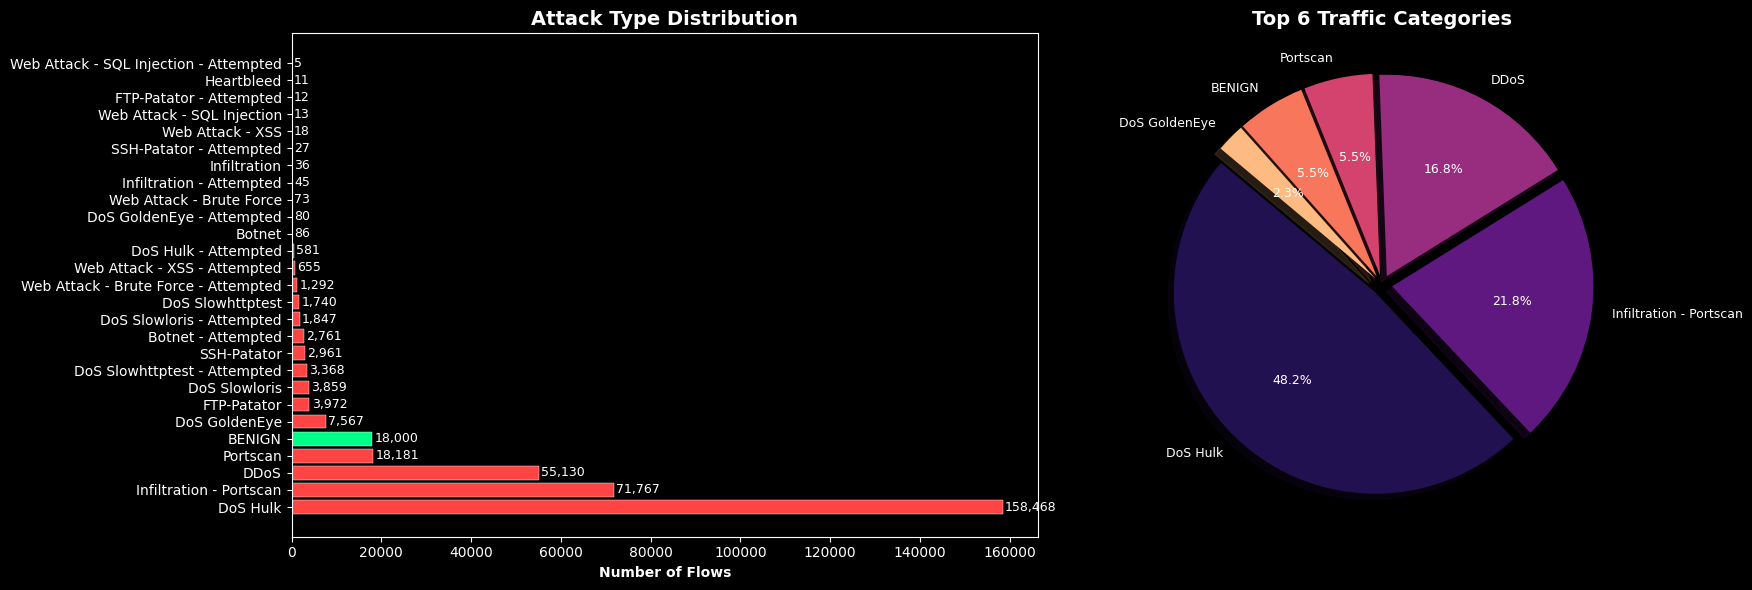

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Bar chart
label_counts = df["Label"].value_counts()
colors = ["#00ff88" if l == "BENIGN" else "#ff4444" for l in label_counts.index]
axes[0].barh(label_counts.index, label_counts.values, color=colors, edgecolor="white", linewidth=0.3)
axes[0].set_xlabel("Number of Flows", fontweight="bold")
axes[0].set_title("Attack Type Distribution", fontsize=14, fontweight="bold")
for i, v in enumerate(label_counts.values):
    axes[0].text(v + 500, i, f"{v:,}", va="center", fontsize=9, color="white")

# Pie chart (top 6)
top_labels = label_counts.head(6)
explode = [0.05] * len(top_labels)
axes[1].pie(top_labels, labels=top_labels.index, autopct="%1.1f%%", explode=explode,
            shadow=True, startangle=140, textprops={"fontsize": 9})
axes[1].set_title("Top 6 Traffic Categories", fontsize=14, fontweight="bold")

plt.tight_layout()
safe_save("attack_distribution.png")
plt.show()

## 3. Feature Engineering & Preprocessing

In [5]:
# Select numeric features for ML
FEATURES = [
    "Flow Duration", "Total Fwd Packet", "Total Bwd packets",
    "Total Length of Fwd Packet", "Total Length of Bwd Packet",
    "Fwd Packet Length Max", "Fwd Packet Length Min", "Fwd Packet Length Mean",
    "Bwd Packet Length Max", "Bwd Packet Length Min", "Bwd Packet Length Mean",
    "Flow Bytes/s", "Flow Packets/s",
    "Flow IAT Mean", "Flow IAT Std", "Flow IAT Max",
    "Fwd IAT Total", "Bwd IAT Total",
    "Fwd Header Length", "Bwd Header Length",
    "Packet Length Mean", "Packet Length Std",
    "FIN Flag Count", "SYN Flag Count", "RST Flag Count", "PSH Flag Count", "ACK Flag Count",
    "Average Packet Size", "Dst Port"
]

# Clean infinities and NaN
X = df[FEATURES].copy()
X = X.replace([np.inf, -np.inf], np.nan).fillna(0)

# Encode labels: BENIGN = 0, Attack = 1
y_binary = (df["Label"] != "BENIGN").astype(int)
y_multi = df["Label"].copy()

print(f"Features: {len(FEATURES)}")
print(f"Benign: {(y_binary == 0).sum():,}  |  Attacks: {(y_binary == 1).sum():,}")

Features: 29
Benign: 18,000  |  Attacks: 334,556


## 4. Feature Correlation Heatmap

Saved plot: correlation_heatmap.png


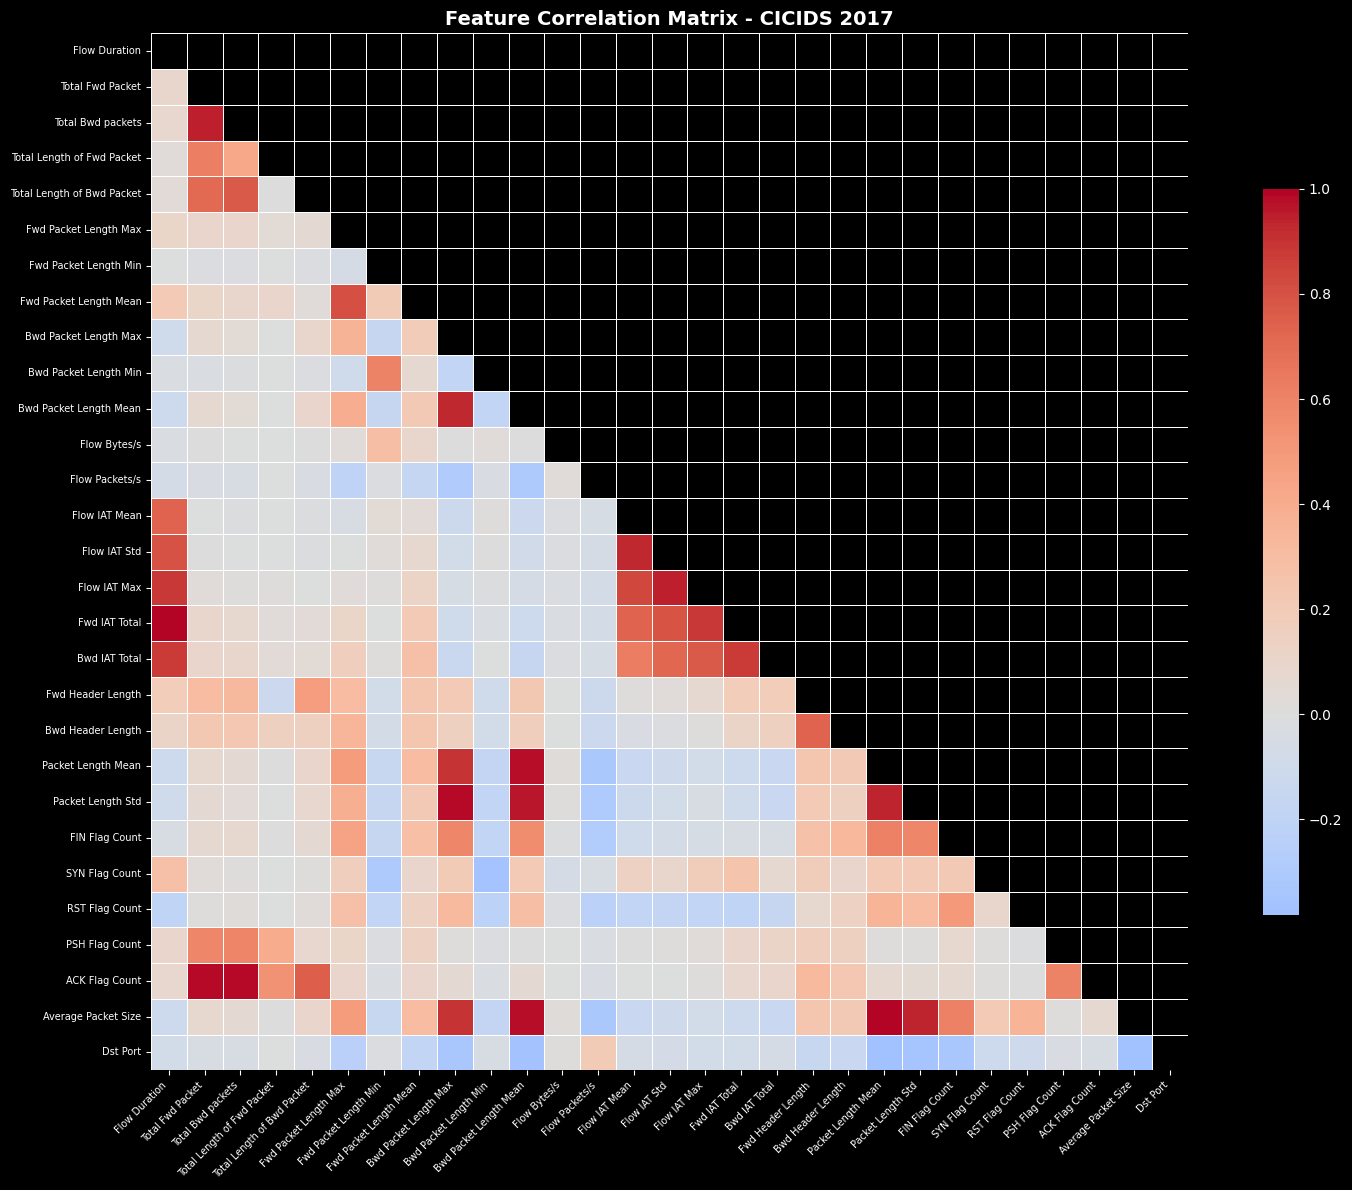

In [6]:
fig, ax = plt.subplots(figsize=(16, 12))
corr = X.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap="coolwarm", center=0, ax=ax,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.7},
            xticklabels=True, yticklabels=True)
ax.set_title("Feature Correlation Matrix - CICIDS 2017", fontsize=14, fontweight="bold")
plt.xticks(fontsize=7, rotation=45, ha="right")
plt.yticks(fontsize=7)
plt.tight_layout()
safe_save("correlation_heatmap.png")
plt.show()

## 5. PCA - Anomaly Visualization (2D Projection)

Saved plot: pca_scatter.png


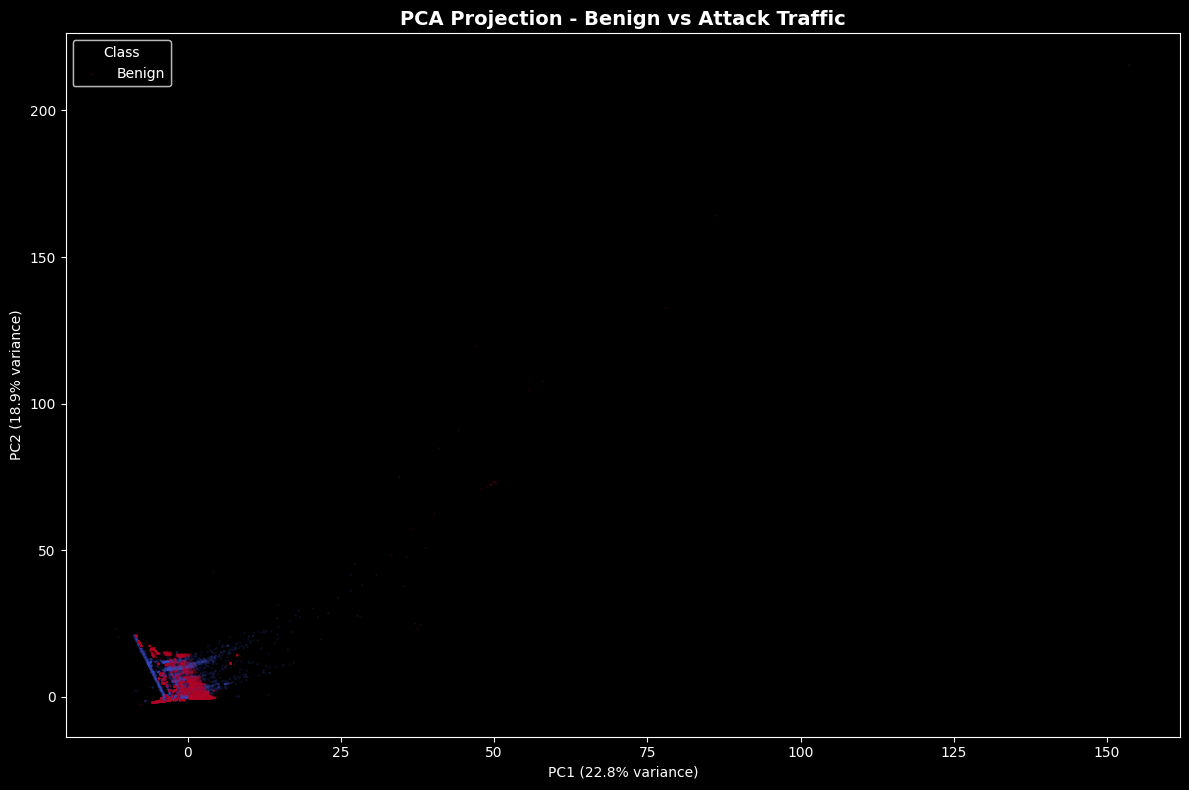

Explained variance: PC1=22.8%, PC2=18.9%


In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(12, 8))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=y_binary, cmap="coolwarm",
                     alpha=0.15, s=3, edgecolors="none")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
ax.set_title("PCA Projection - Benign vs Attack Traffic", fontsize=14, fontweight="bold")
legend = ax.legend(*scatter.legend_elements(), title="Class", labels=["Benign", "Attack"])
ax.add_artist(legend)
plt.tight_layout()
safe_save("pca_scatter.png")
plt.show()
print(f"Explained variance: PC1={pca.explained_variance_ratio_[0]*100:.1f}%, PC2={pca.explained_variance_ratio_[1]*100:.1f}%")

## 6. Anomaly Detection - IsolationForest

In [8]:
iso = IsolationForest(n_estimators=200, contamination=0.15, random_state=42, n_jobs=-1)
iso.fit(X_scaled)

y_iso_pred = iso.predict(X_scaled)  # -1 = anomaly, 1 = normal
y_iso_binary = (y_iso_pred == -1).astype(int)

print("IsolationForest Results:")
print(f"  Detected anomalies: {y_iso_binary.sum():,} / {len(y_iso_binary):,}")
print(f"  Actual attacks:     {y_binary.sum():,}")
print()
print(classification_report(y_binary, y_iso_binary, target_names=["Benign", "Attack"]))

IsolationForest Results:
  Detected anomalies: 52,861 / 352,556
  Actual attacks:     334,556



              precision    recall  f1-score   support

      Benign       0.00      0.03      0.00     18000
      Attack       0.67      0.11      0.18    334556

    accuracy                           0.10    352556
   macro avg       0.34      0.07      0.09    352556
weighted avg       0.64      0.10      0.17    352556



## 7. Supervised Classification - Random Forest

Train a real multi-class classifier to distinguish attack types.

In [9]:
# Encode multi-class labels
le = LabelEncoder()
y_encoded = le.fit_transform(y_multi)

# Filter out classes with only 1 member to avoid split error
counts = np.bincount(y_encoded)
valid_classes = np.where(counts >= 2)[0]
mask = np.isin(y_encoded, valid_classes)
X_final = X_scaled[mask]
y_final = y_encoded[mask]

X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_final, test_size=0.2, random_state=42, stratify=y_final
)

rf = RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Random Forest Accuracy: {acc*100:.2f}%")
print()
# Get filtered target names
filtered_classes = [le.classes_[i] for i in valid_classes]
print(classification_report(y_test, y_pred, target_names=filtered_classes))

Random Forest Accuracy: 98.71%

                                        precision    recall  f1-score   support

                                BENIGN       1.00      0.99      1.00      3600
                                Botnet       1.00      1.00      1.00        17
                    Botnet - Attempted       1.00      1.00      1.00       552
                                  DDoS       1.00      1.00      1.00     11026
                         DoS GoldenEye       1.00      1.00      1.00      1513
             DoS GoldenEye - Attempted       0.80      0.75      0.77        16
                              DoS Hulk       1.00      1.00      1.00     31694
                  DoS Hulk - Attempted       0.97      0.97      0.97       116
                      DoS Slowhttptest       1.00      1.00      1.00       348
          DoS Slowhttptest - Attempted       0.99      0.99      0.99       674
                         DoS Slowloris       1.00      1.00      1.00       772
       

## 8. Confusion Matrix

Saved plot: confusion_matrix.png


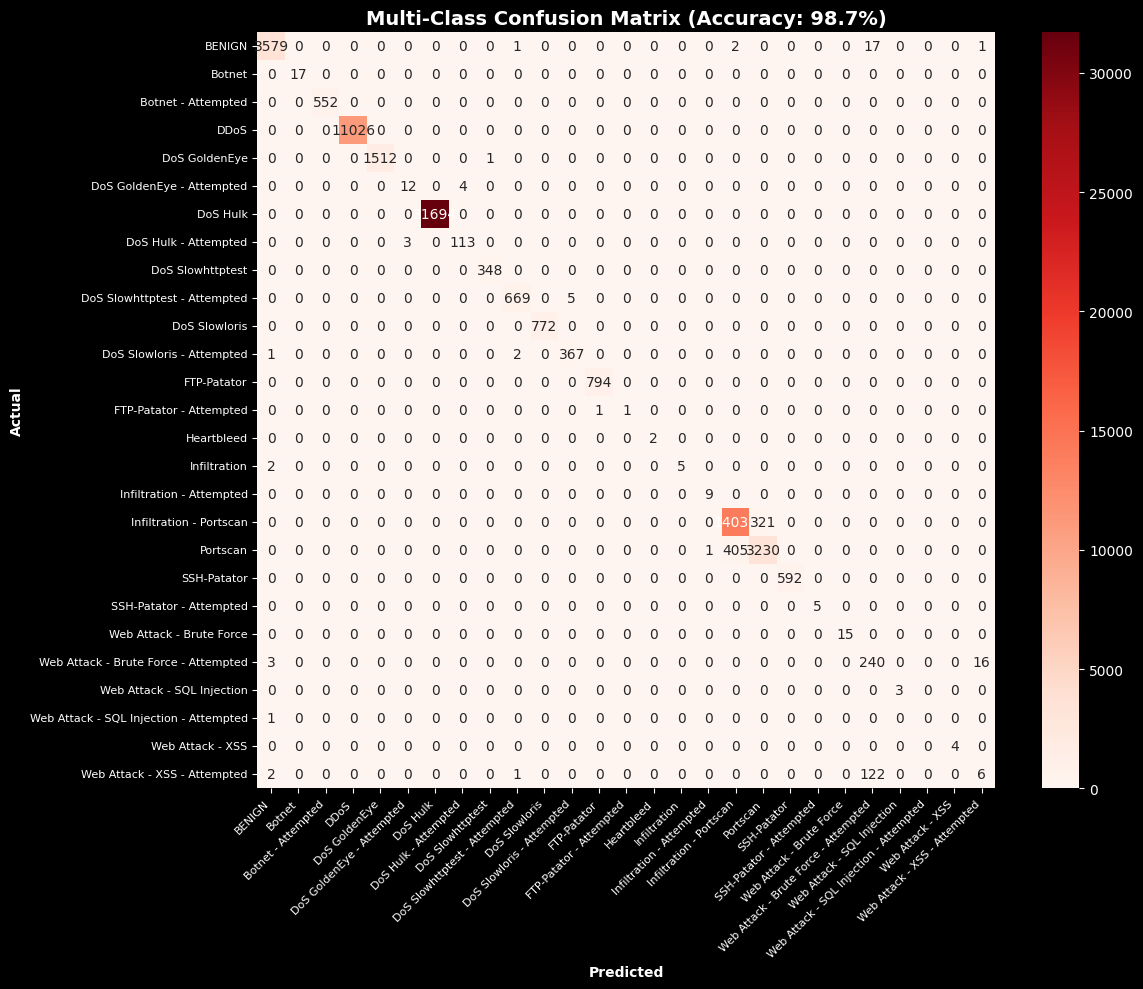

In [10]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds",
            xticklabels=filtered_classes, yticklabels=filtered_classes, ax=ax)
ax.set_xlabel("Predicted", fontweight="bold")
ax.set_ylabel("Actual", fontweight="bold")
ax.set_title(f"Multi-Class Confusion Matrix (Accuracy: {acc*100:.1f}%)", fontsize=14, fontweight="bold")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
safe_save("confusion_matrix.png")
plt.show()

## 9. Feature Importance - What Reveals an Attack?

Saved plot: feature_importance.png


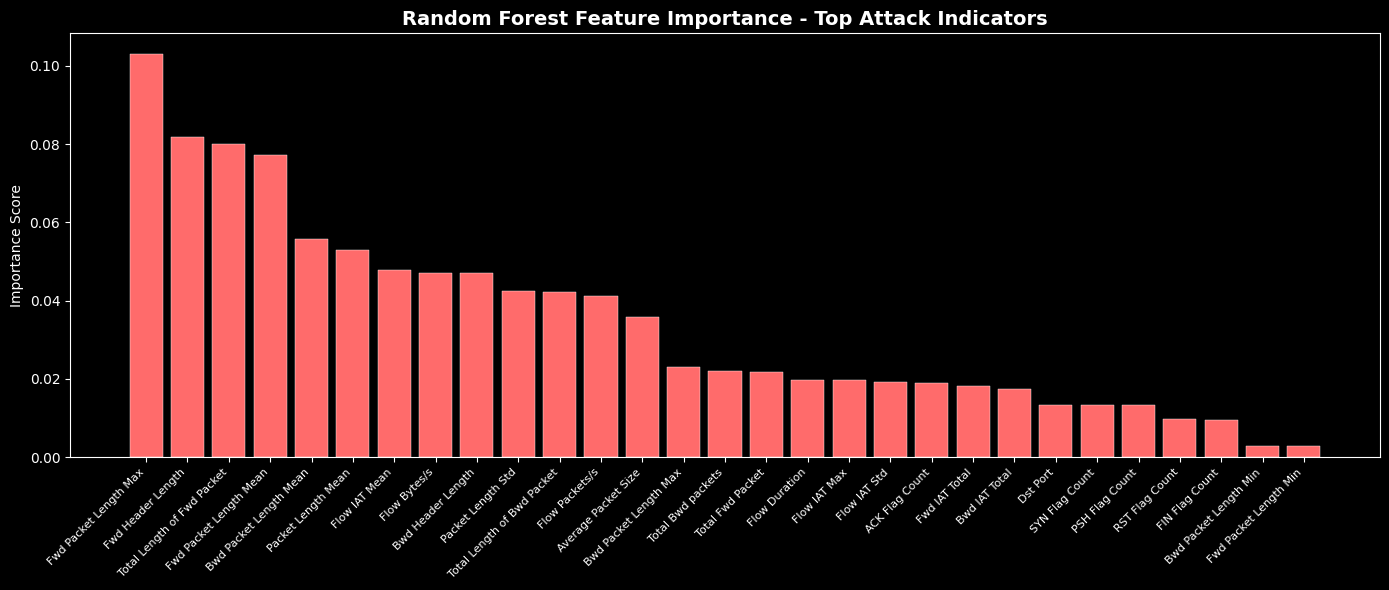

Top 5 features:
  Fwd Packet Length Max: 0.1031
  Fwd Header Length: 0.0818
  Total Length of Fwd Packet: 0.0801
  Fwd Packet Length Mean: 0.0772
  Bwd Packet Length Mean: 0.0559


In [11]:
importances = rf.feature_importances_
idx = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(range(len(FEATURES)), importances[idx], color="#ff6b6b", edgecolor="white", linewidth=0.3)
ax.set_xticks(range(len(FEATURES)))
ax.set_xticklabels([FEATURES[i] for i in idx], rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Importance Score")
ax.set_title("Random Forest Feature Importance - Top Attack Indicators", fontsize=14, fontweight="bold")
plt.tight_layout()
safe_save("feature_importance.png")
plt.show()

print("Top 5 features:")
for i in idx[:5]:
    print(f"  {FEATURES[i]}: {importances[i]:.4f}")

## 10. Targeted Port Analysis

Saved plot: targeted_ports.png


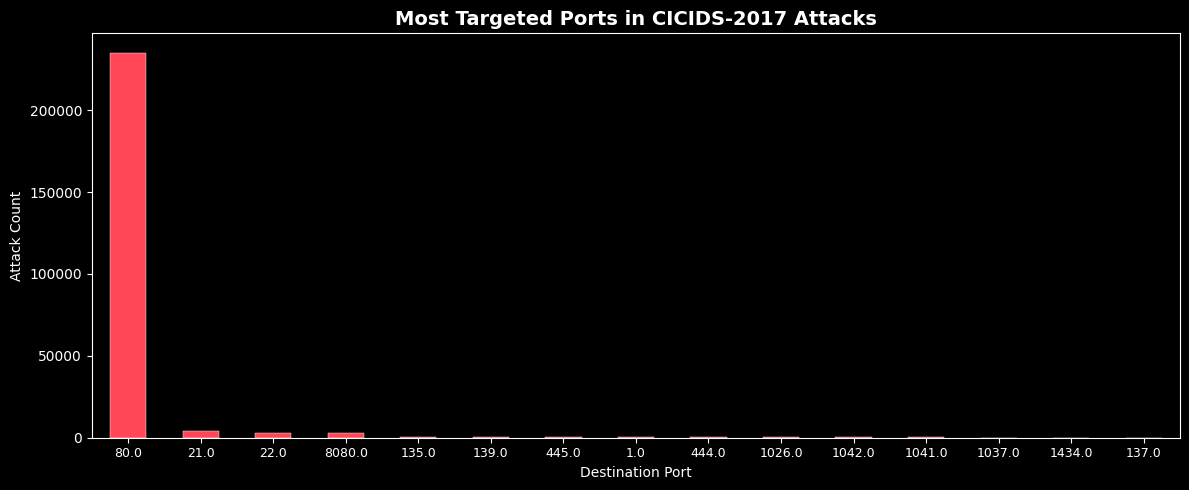

In [12]:
attack_df = df[df["Label"] != "BENIGN"].copy()
port_counts = attack_df["Dst Port"].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 5))
port_counts.plot(kind="bar", ax=ax, color="#ff4757", edgecolor="white", linewidth=0.3)
ax.set_xlabel("Destination Port")
ax.set_ylabel("Attack Count")
ax.set_title("Most Targeted Ports in CICIDS-2017 Attacks", fontsize=14, fontweight="bold")
plt.xticks(rotation=0, fontsize=9)
plt.tight_layout()
safe_save("targeted_ports.png")
plt.show()

## 11. Export Production Model

Save the trained model for the BOUCLIER backend API.

In [13]:
import joblib
import os

MODEL_DIR = "app/ml"
if not os.path.exists(MODEL_DIR):
    MODEL_DIR = "../app/ml"

joblib.dump(iso, os.path.join(MODEL_DIR, "anomaly_model.pkl"))
joblib.dump(scaler, os.path.join(MODEL_DIR, "scaler.pkl"))
joblib.dump(pca, os.path.join(MODEL_DIR, "pca.pkl"))
joblib.dump(rf, os.path.join(MODEL_DIR, "rf_classifier.pkl"))
joblib.dump(le, os.path.join(MODEL_DIR, "label_encoder.pkl"))

print("Models exported:")
for f in ["anomaly_model.pkl", "scaler.pkl", "pca.pkl", "rf_classifier.pkl", "label_encoder.pkl"]:
    path = os.path.join(MODEL_DIR, f)
    if os.path.exists(path):
        size = os.path.getsize(path) / 1024
        print(f"  {f}: {size:.0f} KB")

Models exported:
  anomaly_model.pkl: 1631 KB
  scaler.pkl: 2 KB
  pca.pkl: 2 KB
  rf_classifier.pkl: 34494 KB
  label_encoder.pkl: 1 KB


## 12. Executive Summary

| Metric | Value |
|--------|-------|
| Dataset | CICIDS-2017 (Canadian Institute for Cybersecurity) |
| Records | ~350,000 network flows |
| Features | 29 selected from 87 |
| IsolationForest | Unsupervised anomaly detection |
| RandomForest | Supervised multi-class classification |
| Exported Models | `anomaly_model.pkl`, `rf_classifier.pkl`, `scaler.pkl`, `pca.pkl` |

---

**BOUCLIER SAAS** uses these models in production for real-time threat detection.